# **CSL2050: Pattern Recognition and Machine Learning**
## **Course Project: Hand-drawn Sketch Recognition**

### **Step 1:** Importing the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

# Define paths
zip_path = "/content/drive/MyDrive/Dataset_PNG.zip"  # Change this if needed
extract_path = "/content/Dataset_PNG"  # Folder where dataset will be extracted

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extraction
os.listdir(extract_path)  # Should show "png" folder inside

['sketches_png']

In [ ]:
dataset_path = "/content/Dataset_PNG/sketches_png/png"

# Check the extracted dataset folder
print(os.listdir(dataset_path))  # Should show category folders like 'zebra', 'cat', etc.

# Check some images inside a category
sample_category = os.path.join(dataset_path, "zebra")  # Change to any category name
print(os.listdir(sample_category)[:5])  # List first 5 images

['radio', 'pretzel', 'wheelbarrow', 'mailbox', 'purse', 'tooth', 'ipod', 'toilet', 'satellite dish', 'parrot', 'sheep', 'frog', 'stapler', 'shovel', 'space shuttle', 'floor lamp', 'hammer', 'beer-mug', 'angel', 'backpack', 'bush', 'truck', 'motorbike', 'butterfly', 'rainbow', 'basket', 'arm', 'tomato', 'vase', 'tree', 'dog', 'door', 'cigarette', 'bench', 'flashlight', 'squirrel', 'trousers', 'hat', 'giraffe', 'head', 'train', 'wrist-watch', 'donut', 'head-phones', 'potted plant', 'fork', 'elephant', 'spider', 'bottle opener', 'candle', 'ant', 'binoculars', 'dolphin', 'hot air balloon', 'bed', 'sword', 'windmill', 'helmet', 'pipe (for smoking)', 'violin', 'rifle', 'sponge bob', 'computer-mouse', 'owl', 'spoon', 'bicycle', 'snail', 'ashtray', 'rooster', 'teacup', 'monkey', 'eye', 'swan', 'shark', 'calculator', 'fan', 'ship', 'computer monitor', 'fish', 'mushroom', 'bee', 'axe', 'airplane', 'hand', 'crane (machine)', 'hedgehog', 'toothbrush', 'nose', 'diamond', 'feather', 'microscope', 'w

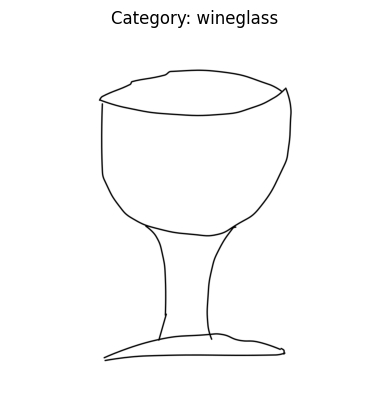

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random

# Pick a random category
categories = os.listdir(dataset_path)
random_category = random.choice(categories)

# Pick a random image from the category
image_folder = os.path.join(dataset_path, random_category)
image_name = random.choice(os.listdir(image_folder))
image_path = os.path.join(image_folder, image_name)

# Load and display the image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
plt.imshow(image, cmap='gray')
plt.title(f"Category: {random_category}")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np
import cv2
import os
from skimage.feature import hog, local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# === Step 1: Load Images and Extract Features ===
categories = os.listdir(dataset_path)
data = []
labels = []

for category in categories:
    category_path = os.path.join(dataset_path, category)
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
        img = cv2.resize(img, (64, 64))  # Resize to 64x64

        # Compute HOG Features
        hog_features = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2))

        # Compute LBP Features (Fix floating point warning)
        lbp = local_binary_pattern((img * 255).astype(np.uint8), P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)  # LBP histogram

        # Concatenate HOG and LBP features
        combined_features = np.hstack((hog_features, lbp_hist))
        data.append(combined_features)
        labels.append(category)

# Convert to NumPy arrays
data = np.array(data)
labels = np.array(labels)

# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# === Step 2: Split Data & Normalize ===
X_train, X_test, y_train, y_test = train_test_split(data, labels_encoded, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === Step 3: Train SVM Classifier ===
svm_clf = SVC(kernel='linear')  # Try 'rbf' or 'poly' if needed
svm_clf.fit(X_train_scaled, y_train)

# === Step 4: Make Predictions ===
y_pred = svm_clf.predict(X_test_scaled)

# === Step 5: Evaluate Accuracy ===
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Accuracy: {accuracy * 100:.2f}%")

SVM Accuracy: 17.22%


In [ ]:
svm_clf = SVC(kernel='rbf', C=100)  # Try 'rbf' or 'poly' if needed
svm_clf.fit(X_train_scaled, y_train)

# === Step 4: Make Predictions ===
y_pred = svm_clf.predict(X_test_scaled)

# === Step 5: Evaluate Accuracy ===
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Accuracy: {accuracy * 100:.2f}%")

SVM Accuracy: 18.50%


In [ ]:
svm_clf = SVC(kernel='poly', degree=3, C=1.0)  # Try 'rbf' or 'poly' if needed
svm_clf.fit(X_train_scaled, y_train)

# === Step 4: Make Predictions ===
y_pred = svm_clf.predict(X_test_scaled)

# === Step 5: Evaluate Accuracy ===
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Accuracy: {accuracy * 100:.2f}%")

SVM Accuracy: 1.20%


In [ ]:
from sklearn.decomposition import PCA

# Reduce dimensions with PCA
pca = PCA(n_components=150)  # Try 50, 100, 150
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train SVM on PCA-transformed data
svm_clf = SVC(kernel='rbf', C=650)
svm_clf.fit(X_train_pca, y_train)

# Predictions and Accuracy
y_pred = svm_clf.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Accuracy with PCA: {accuracy * 100:.2f}%")

SVM Accuracy with PCA: 19.98%
